In [155]:
from dotenv import load_dotenv, find_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv(find_dotenv())

path = os.getenv('POST_STANDARDIZATION_DATA_SOURCE')

# Read data from csv file and create DataFrame:
csv_data = pd.read_csv(path, sep=',')
df = pd.DataFrame(csv_data)

## TODO
- Build plots for the distribution of each column
- Check for outliers and anomalies

In [156]:
numeric_columns = list(df.select_dtypes(include=["number"]).columns)
numeric_columns.remove("senior_citizen")
numeric_columns.remove("has_phone_service")
numeric_columns.remove("has_internet_service")
numeric_columns.remove("has_online_security")
numeric_columns.remove("has_online_backup")
numeric_columns.remove("has_device_protection")
numeric_columns.remove("has_tech_support")
numeric_columns.remove("has_streaming_tv")
numeric_columns.remove("has_streaming_movies")
numeric_columns.remove("churn")
print(len(numeric_columns))

14


In [169]:
def build_numeric_histogram(df: pd.DataFrame, column_name: str, index: int):
    ax = plt.subplot(3, 2, index)
    n, bins, patches = ax.hist(df[column_name], bins=7, rwidth=0.85)
    ax.bar_label(patches, fmt='%d', fontsize=7, padding=2)
    ax.grid(visible=True)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {column_name}", pad=20)

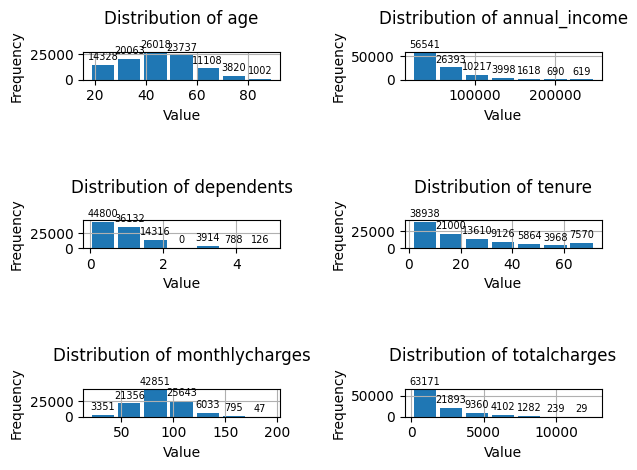

In [170]:
for idx, column_name in enumerate(numeric_columns[0:6]):
    build_numeric_histogram(df, column_name, idx + 1)

plt.tight_layout(h_pad=4, w_pad=3)
plt.show()

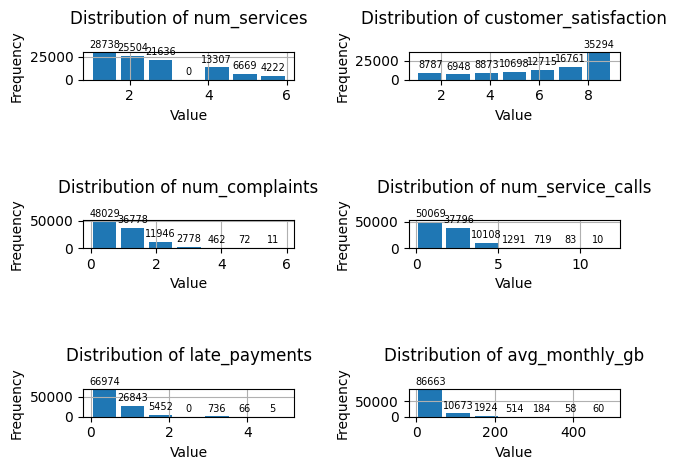

In [171]:
for idx, column_name in enumerate(numeric_columns[6:12]):
    build_numeric_histogram(df, column_name, idx + 1)

plt.tight_layout(h_pad=4, w_pad=3)
plt.show()

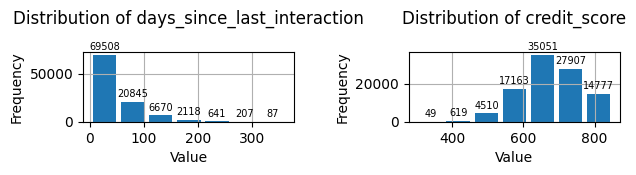

In [172]:
for idx, column_name in enumerate(numeric_columns[12:14]):
    build_numeric_histogram(df, column_name, idx + 1)

plt.tight_layout(h_pad=4, w_pad=3)
plt.show()

In [173]:
categorical_columns = list(df.select_dtypes(exclude=["number"]).columns)
categorical_columns.remove("customer_id")
categorical_columns.extend([
    "senior_citizen",
    "has_phone_service",
    "has_internet_service",
    "has_online_security",
    "has_online_backup",
    "has_device_protection",
    "has_tech_support",
    "has_streaming_tv",
    "has_streaming_movies",
])
print(len(categorical_columns))

15


In [174]:
def build_categorical_bar_chart(df: pd.DataFrame, column_name: str, index: int):
    is_binary_col = set(df[column_name].dropna().unique()) <= {0, 1}
    col = df[column_name].map({0: "No", 1: "Yes"}) if is_binary_col else df[column_name]
    counts = col.value_counts()

    ax = plt.subplot(3, 1, index)
    bars = ax.bar(x=counts.index, height=counts.values, color="skyblue")
    ax.bar_label(bars, fmt='%d', padding=3)
    ax.grid(visible=True)
    ax.set_xlabel("Category")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {column_name}", pad=20)

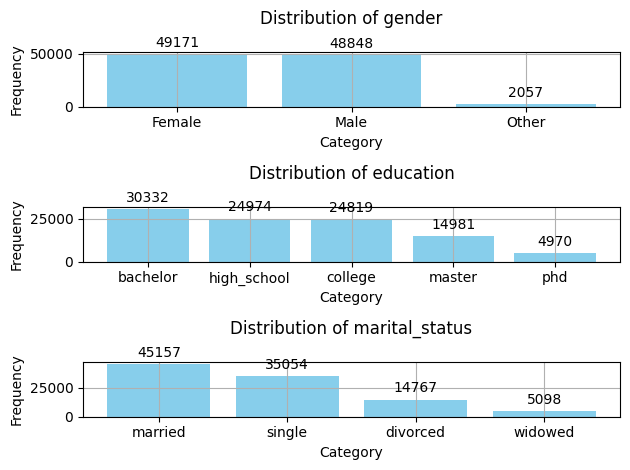

In [175]:
for idx, column in enumerate(categorical_columns[0:3]):
    build_categorical_bar_chart(df, column, idx + 1)

plt.tight_layout()
plt.show()

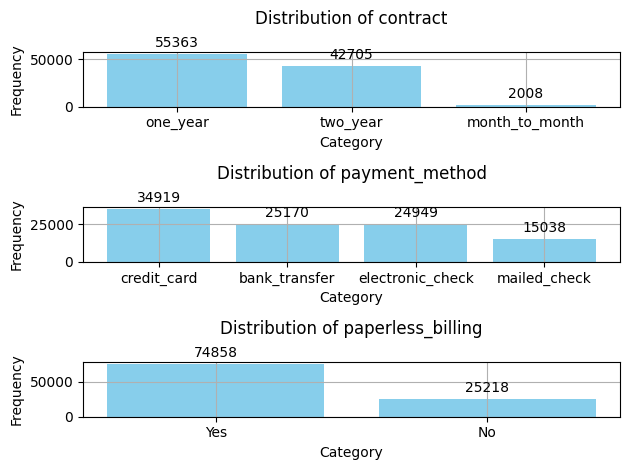

In [176]:
for idx, column in enumerate(categorical_columns[3:6]):
    build_categorical_bar_chart(df, column, idx + 1)

plt.tight_layout()
plt.show()

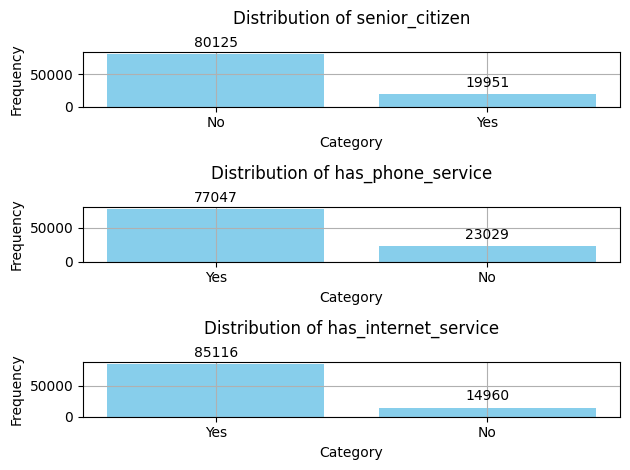

In [177]:
for idx, column in enumerate(categorical_columns[6:9]):
    build_categorical_bar_chart(df, column, idx + 1)

plt.tight_layout()
plt.show()

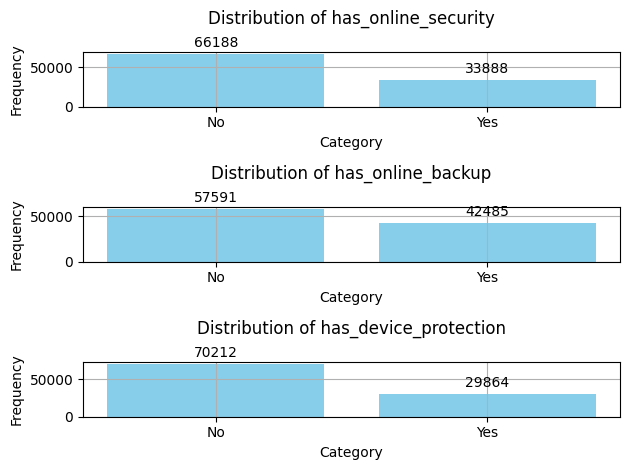

In [178]:
for idx, column in enumerate(categorical_columns[9:12]):
    build_categorical_bar_chart(df, column, idx + 1)

plt.tight_layout()
plt.show()


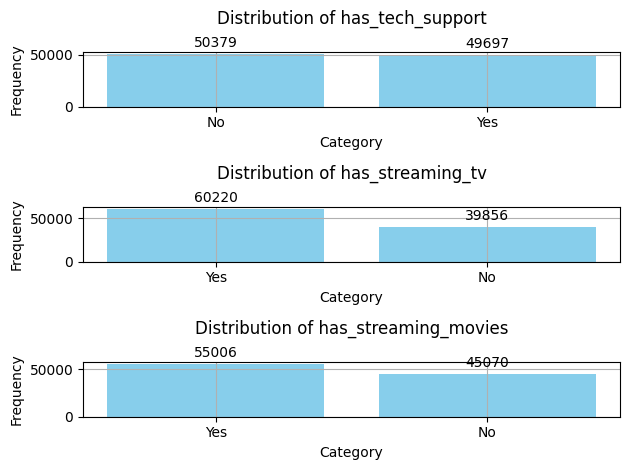

In [179]:
for idx, column in enumerate(categorical_columns[12:15]):
    build_categorical_bar_chart(df, column, idx + 1)

plt.tight_layout()
plt.show()

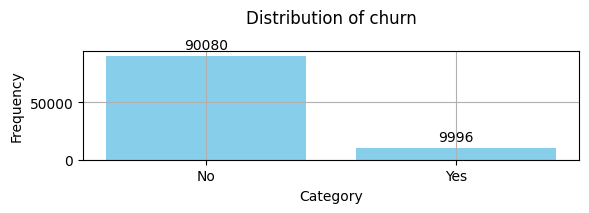

In [180]:
build_categorical_bar_chart(df, "churn", 1)
plt.show()